## Libraries and Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import contractions
from nltk.downloader import download
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
download('popular')

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /home/jeffmoe/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /home/jeffmoe/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /home/jeffmoe/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /home/jeffmoe/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     /home/jeffmoe/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /home/jeffmoe/nltk_data...
[nltk_data]    |   Package movie_reviews is already

True

## Text Preprocessing

In [4]:
def preprocess(text:str | list ) -> tuple[list, list]:
    '''
    Function to preprocess the text for vectorization.
    Returns:
        (word_tokens, sentence_tokens)
    '''
    try:
        # check the input for dtype. Raise error if not string or list
        if isinstance(text, list):
            text = ' '.join(text)
        elif not isinstance(text, str):
            raise ValueError("Input must be a list or string")
        text = contractions.fix(text) # Expand contractions first
        stop_words = set(stopwords.words('english')) # init stop words list from NLTK
        lemmatizer = WordNetLemmatizer() # init lemmatizer from NLTK

        tokens_sentences = nltk.sent_tokenize(text)
        normalized_tokens_sentences =[]
        for sentence in tokens_sentences:
            word = nltk.word_tokenize(sentence)
            word = [
                re.sub(r'[^a-zA-Z0-9]', '', w.lower())
                for w in word
            ] # normalize
            word = [w for w in word if w and w not in stop_words] # remove stop words
            word = [lemmatizer.lemmatize(w) for w in word] # reduce words to base values
            normalized_tokens_sentences.append(' '.join(word)) # combine back into sentence structure

        

        normalized_tokens_words = nltk.word_tokenize(text)
        normalized_tokens_words = [
            re.sub(r'[^a-zA-Z0-9]', '', w.lower()) 
            for w in normalized_tokens_words
            ] # normalize
        normalized_tokens_words = [w for w in normalized_tokens_words if w and w not in stop_words] # remove stop words
        normalized_tokens_words = [lemmatizer.lemmatize(w) for w in normalized_tokens_words] # reduce words to base values
        

        
        return normalized_tokens_words, normalized_tokens_sentences
    except Exception as e:
        print(f"Error in preprocesssing: {e}")
        return [], []

In [32]:
sample_text_1 = """
Justin Jefferson is an American professional football wide receiver widely regarded as one of the best players in the NFL. 
Drafted in 2020 by the Minnesota Vikings, 
he is famous for his elite route-running, sure hands, and explosive playmaking."""
sample_text_2 = """
Justin Jefferson is an American professional football player widely regarded as one 
of the most elite wide receivers in the NFL. 
Drafted by the Minnesota Vikings in 2020 out of LSU, 
he is famous for his exceptional route-running, physics-defying contested catches, 
and ability to generate massive yardage."""
sample_text_3 = """
Xbox Game Pass is a rotating video game subscription service by Microsoft that allows 
members to download or stream hundreds of games across 
Xbox consoles, PC, and cloud-compatible devices for a flat monthly fee."""
sample_text_4 = """
A car (or automobile) is a wheeled, self-propelled motor vehicle designed primarily for personal transport on roads. 
It typically seats one to eight people, relies on an internal combustion engine, 
electric motor, or hybrid system, and uses four wheels to move."""

In [37]:
print(f"Sample 1: {preprocess(sample_text_1)}")
print(f"Sample 2: {preprocess(sample_text_2)}")
print(f"Sample 3: {preprocess(sample_text_3)}")
print(f"Sample 4: {preprocess(sample_text_4)}")

processed_1 = preprocess(sample_text_1)
processed_2 = preprocess(sample_text_2)
processed_3 = preprocess(sample_text_3)
processed_4 = preprocess(sample_text_4)

combined_docs = []
combined_docs = [processed_1[0],processed_2[0],processed_3[0],processed_4[0]]
combined_docs

Sample 1: (['justin', 'jefferson', 'american', 'professional', 'football', 'wide', 'receiver', 'widely', 'regarded', 'one', 'best', 'player', 'nfl', 'drafted', '2020', 'minnesota', 'viking', 'famous', 'elite', 'routerunning', 'sure', 'hand', 'explosive', 'playmaking'], ['justin jefferson american professional football wide receiver widely regarded one best player nfl', 'drafted 2020 minnesota viking famous elite routerunning sure hand explosive playmaking'])
Sample 2: (['justin', 'jefferson', 'american', 'professional', 'football', 'player', 'widely', 'regarded', 'one', 'elite', 'wide', 'receiver', 'nfl', 'drafted', 'minnesota', 'viking', '2020', 'lsu', 'famous', 'exceptional', 'routerunning', 'physicsdefying', 'contested', 'catch', 'ability', 'generate', 'massive', 'yardage'], ['justin jefferson american professional football player widely regarded one elite wide receiver nfl', 'drafted minnesota viking 2020 lsu famous exceptional routerunning physicsdefying contested catch ability ge

[['justin',
  'jefferson',
  'american',
  'professional',
  'football',
  'wide',
  'receiver',
  'widely',
  'regarded',
  'one',
  'best',
  'player',
  'nfl',
  'drafted',
  '2020',
  'minnesota',
  'viking',
  'famous',
  'elite',
  'routerunning',
  'sure',
  'hand',
  'explosive',
  'playmaking'],
 ['justin',
  'jefferson',
  'american',
  'professional',
  'football',
  'player',
  'widely',
  'regarded',
  'one',
  'elite',
  'wide',
  'receiver',
  'nfl',
  'drafted',
  'minnesota',
  'viking',
  '2020',
  'lsu',
  'famous',
  'exceptional',
  'routerunning',
  'physicsdefying',
  'contested',
  'catch',
  'ability',
  'generate',
  'massive',
  'yardage'],
 ['xbox',
  'game',
  'pas',
  'rotating',
  'video',
  'game',
  'subscription',
  'service',
  'microsoft',
  'allows',
  'member',
  'download',
  'stream',
  'hundred',
  'game',
  'across',
  'xbox',
  'console',
  'pc',
  'cloudcompatible',
  'device',
  'flat',
  'monthly',
  'fee'],
 ['car',
  'automobile',
  'whee

## Vectorization and Cosine Similarity

In [ ]:
def cosine_sim(token: list | tuple) -> list:
    '''
    Function to use TF-IDF to vectorize tokens + apply cosine similarity
    Returns:
        (cos_sim_matrix)
    '''
    token = [' '.join(t) for t in token] # join tokens back into strings for vectorization
    vectorizer = TfidfVectorizer() # init the TF-IDF method
    X_sklearn = vectorizer.fit_transform(token)

    cos_sim_sklearn = cosine_similarity(X_sklearn) # calculate the similarity based on the document vectors
    return cos_sim_sklearn


In [39]:
print(cosine_sim(combined_docs))
cos_sim_sklearn= cosine_sim(combined_docs)

[[1.         0.62721457 0.         0.0184417 ]
 [0.62721457 1.         0.         0.01655432]
 [0.         0.         1.         0.        ]
 [0.0184417  0.01655432 0.         1.        ]]


## Visualizing Vectors and Matrices

In [ ]:
def graph_vectors(cos_sim_matrix):
    '''
    Visualization of vectors and cos sim matrix from Sklearn.
    Returns:
        - Cosine Similarity Matrix
        - Angles Between Document Vectors Matrix
    '''

    plt.figure(figsize=(7, 6))
    sns.heatmap(cos_sim_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1) #correlation plot for cosine similarity
    plt.title("Cosine similarity matrix")
    plt.show()

    plt.figure(figsize=(7,6))
    angles = np.degrees(np.arccos(np.clip(cos_sim_matrix, -1.0, 1.0))) # Using numPy to get the angle between vectors
    sns.heatmap(angles, annot=True, cmap="viridis")
    plt.title("Pairwise Angles Between Vectors")
    plt.xlabel("Document")
    plt.ylabel("Document")
    plt.show()




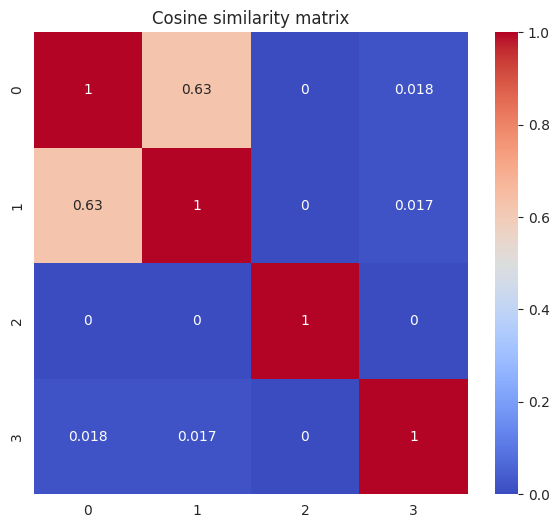

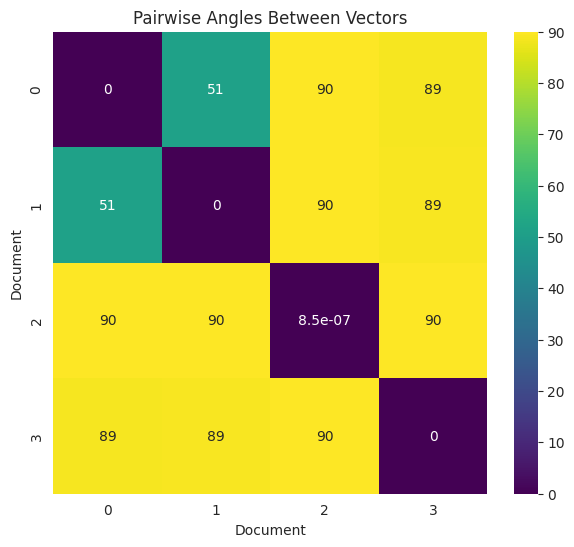

In [41]:
graph_vectors(cos_sim_sklearn)